<a href="https://colab.research.google.com/github/piper56M/DinoClassifier/blob/main/DinosaurClass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
uploaded = files.upload()

Saving dinosaurs.csv to dinosaurs.csv


In [4]:
import pandas as pd

data = pd.read_csv("dinosaurs.csv")
print(data)

                Name  Length_m  Weight_kg  Teeth_length_cm       Diet
0  Tyrannosaurus Rex     12.00       8000            30.00  carnivore
1        Triceratops      9.00       6000             0.50  herbivore
2        Stegosaurus      9.00       1600             1.00  herbivore
3         Allosaurus      8.50       1500             5.00  carnivore
4       Ankylosaurus      6.25       6000             0.75  herbivore
5       Velociraptor      2.00         15             2.00  carnivore
6      Brachiosaurus     20.00      30000             3.97  herbivore
7      Gigantosaurus     12.00       7000            20.00  carnivore
8        Diplodocus      24.00      12000             2.54  herbivore
9        Spinosaurus     14.00       7000            12.00  carnivore


In [5]:
x = data[["Length_m", "Weight_kg", "Teeth_length_cm"]]
y = data["Diet"]

print(x)
print(y)

   Length_m  Weight_kg  Teeth_length_cm
0     12.00       8000            30.00
1      9.00       6000             0.50
2      9.00       1600             1.00
3      8.50       1500             5.00
4      6.25       6000             0.75
5      2.00         15             2.00
6     20.00      30000             3.97
7     12.00       7000            20.00
8     24.00      12000             2.54
9     14.00       7000            12.00
0    carnivore
1    herbivore
2    herbivore
3    carnivore
4    herbivore
5    carnivore
6    herbivore
7    carnivore
8    herbivore
9    carnivore
Name: Diet, dtype: object


In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()


In [8]:
model.fit(X_train, y_train)

LogisticRegression()

In [9]:
predictions = model.predict(X_test)

In [10]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Model accuracy:", accuracy)

Model accuracy: 1.0


In [11]:
new_dino = [[2, 28, 6.5]]

prediction = model.predict(new_dino)

print("Predicted diet:", prediction[0])

Predicted diet: carnivore


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [12]:
new_dino = [[1.5, 12, 2.5]]

prediction = model.predict(new_dino)

print("Predicted diet:", prediction[0])

Predicted diet: carnivore


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [13]:
new_dino = [[33, 10000, 7]]

prediction = model.predict(new_dino)

print("Predicted diet:", prediction[0])

Predicted diet: herbivore


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [14]:
new_dino = [[5, 650, 2]]

prediction = model.predict(new_dino)

print("Predicted diet:", prediction[0])

Predicted diet: carnivore


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [15]:
import matplotlib.pyplot as plt

In [21]:
data["Diet"] = data["Diet"].str.strip().str.capitalize()
colors = data["Diet"].map({"Carnivore": "red", "Herbivore": "green"})

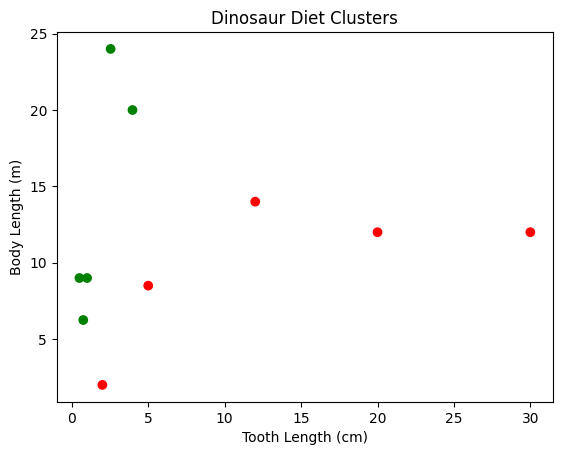

In [22]:
import matplotlib.pyplot as plt

plt.scatter(
    data["Teeth_length_cm"],
    data["Length_m"],
    c=colors
)

plt.xlabel("Tooth Length (cm)")
plt.ylabel("Body Length (m)")
plt.title("Dinosaur Diet Clusters")

plt.show()

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Define features and labels
X_plot = data[["Teeth_length_cm", "Length_m"]].values
y_plot = np.array([1 if diet == "Carnivore" else 0 for diet in data["Diet"]])

In [24]:
from sklearn.linear_model import LogisticRegression

model_2d = LogisticRegression()
model_2d.fit(X_plot, y_plot)

LogisticRegression()

In [25]:
x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
y_min, y_max = X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Predict on each point in the grid
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

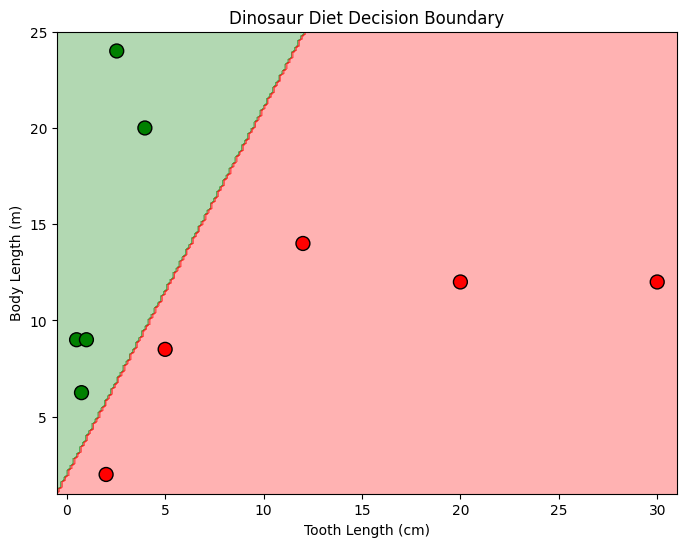

In [26]:
plt.figure(figsize=(8,6))
cmap_light = ListedColormap(['green', 'red'])

plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
plt.scatter(X_plot[:,0], X_plot[:,1], c=y_plot, cmap=ListedColormap(['green','red']), edgecolor='k', s=100)
plt.xlabel("Tooth Length (cm)")
plt.ylabel("Body Length (m)")
plt.title("Dinosaur Diet Decision Boundary")
plt.show()